In [1570]:
#Based on Modern Robotics Library 
import numpy as np 
import modern_robotics as mr
import matplotlib.pyplot as plt 

In [1571]:
#This function will extract components from the calculated matrices and store them in a list
#This function takes in a list of matrices after running trajectory and the gripper status
# outputs a list consisting of the components and status
def extract_components_from_matrix(trajectory_matrices, gripper_status):
    #init row list
    row_list = []
    for M in trajectory_matrices:
        #extracting info from each matrix M in a list of trajectory matrices
        rows = M[0:3, 0:3].flatten() 
        pos = M[0:3, 3]

        #row_format is in form of [r11,r12,r13,r21,r22,r23,r31,r32,r33,px,py,pz,gripper]
        #appending row format into row list
        row_format = [rows[0], rows[1], rows[2], rows[3], rows[4], rows[5], rows[6], rows[7], rows[8], pos[0], pos[1], pos[2], gripper_status]
        row_list.append(row_format)
    return row_list

In [1572]:
#Trajectory Generation Code generates trajectory for the robot 
#inputs: Tse, Tsc_init , Tsc_final, Tce_grasp, Tce_standoff, k 
#all matrices need to be in the form of np.array([[...], [...], ... ])
#outputs a list of all trajectory waypoints (for saving results as .csv file, need to type np.savetxt("trajectory.csv", TrajectoryGenerator(...), delimiter=","))
def TrajectoryGenerator(Tse, Tsc_init, Tsc_final, Tce_grasp, Tce_standoff, k):

    #init waypoint list
    waypoint_list = []
    waypoint_list_matrix = []

    #converting to world frame first for end effector (need to double check if this is correct)
    Tse_grasp_init = Tsc_init @ Tce_grasp
    Tse_grasp_final = Tsc_final @ Tce_grasp
    
    Tse_standoff_init = Tsc_init @ Tce_standoff
    Tse_standoff_final = Tsc_final @ Tce_standoff
    
    #gripper status
    gripper_status =  0 #0 for open, 1 for closed

    #trajectory 1: using CartesianTrajectory to go from Tse to Tse_standoff initial
    #extracting trajectory from matrices and appending to waypoint list
    Tf = 5
    number_of_points = Tf*k/0.01
    trajectory_1 = mr.CartesianTrajectory(Tse, Tse_standoff_init,Tf,number_of_points,5)
    gripper_status = 0
    waypoint_list_matrix.extend(trajectory_1)
    extraction_1 = extract_components_from_matrix(trajectory_1, gripper_status)
    waypoint_list.extend(extraction_1)


    #trajectory 2: using CartesianTrajectory to go from Tse_standoff initial to Tse_grasp initial 
    #extracting trajectory from matrices and appending to waypoint list
    Tf = 3
    number_of_points = (Tf * k / 0.01)
    trajectory_2 = mr.CartesianTrajectory(Tse_standoff_init, Tse_grasp_init,Tf,number_of_points,5)
    gripper_status = 0
    waypoint_list_matrix.extend(trajectory_2)
    extraction_2 = extract_components_from_matrix(trajectory_2, gripper_status)
    waypoint_list.extend(extraction_2)

    #trajectory 3: closing gripper 
    #extracting trajectory from matrices and appending to waypoint list
    Tf = 1
    number_of_points = (Tf * k / 0.01)
    trajectory_3 =  mr.CartesianTrajectory(Tse_grasp_init, Tse_grasp_init, Tf,number_of_points,5)
    gripper_status = 1 
    waypoint_list_matrix.extend(trajectory_3)
    extraction_3 = extract_components_from_matrix(trajectory_3, gripper_status)
    waypoint_list.extend(extraction_3)

    #trajectory 4: using CartesianTrajectory to go to Tse_standoff initial from ground 
    #extracting trajectory from matrices and appending to waypoint list
    Tf = 3
    number_of_points = (Tf * k / 0.01)
    trajectory_4 = mr.CartesianTrajectory(Tse_grasp_init, Tse_standoff_init, Tf,number_of_points,5)
    gripper_status = 1
    waypoint_list_matrix.extend(trajectory_4)
    extraction_4 = extract_components_from_matrix(trajectory_4, gripper_status)
    waypoint_list.extend(extraction_4)

    #trajectory 5: using CartesianTrajectory to go to Tse_standoff final from Tse_standoff initial
    #extracting trajectory from matrices and appending to waypoint list 
    Tf = 5
    number_of_points = (Tf * k / 0.01)
    trajectory_5 = mr.CartesianTrajectory(Tse_standoff_init,Tse_standoff_final, Tf,number_of_points,5)
    gripper_status = 1
    waypoint_list_matrix.extend(trajectory_5)
    extraction_5 = extract_components_from_matrix(trajectory_5, gripper_status)
    waypoint_list.extend(extraction_5)

    #trajectory 6: using CartesianTrajectory to go to the Tse_grasp final of the robot from Tse_standoff final 
    #extracting trajectory from matrices and appending to waypoint list
    Tf = 3
    number_of_points = (Tf * k / 0.01)
    trajectory_6 = mr.CartesianTrajectory(Tse_standoff_final, Tse_grasp_final,Tf, number_of_points,5)
    gripper_status = 1 
    waypoint_list_matrix.extend(trajectory_6)
    extraction_6 = extract_components_from_matrix(trajectory_6, gripper_status)
    waypoint_list.extend(extraction_6)
    
    #trajectory 7: opening gripper
    #extracting trajectory from matrices and appending to waypoint list 
    Tf = 1
    number_of_points = (Tf * k / 0.01)
    trajectory_7 = mr.CartesianTrajectory(Tse_grasp_final, Tse_grasp_final, Tf, number_of_points,5)
    gripper_status = 0 
    waypoint_list_matrix.extend(trajectory_7)
    extraction_7 = extract_components_from_matrix(trajectory_7, gripper_status)
    waypoint_list.extend(extraction_7)

    #trajectory 8: using CartesianTrajectory to finish at Tse_standoff final 
    #extracting trajectory from matrices and appending to waypoint list
    Tf = 3
    number_of_points = (Tf * k / 0.01)
    trajectory_8 = mr.CartesianTrajectory(Tse_grasp_final, Tse_standoff_final, Tf, number_of_points, 5)
    gripper_status = 0 
    waypoint_list_matrix.extend(trajectory_8)
    extraction_8 = extract_components_from_matrix(trajectory_8, gripper_status)
    waypoint_list.extend(extraction_8)

    return waypoint_list, waypoint_list_matrix


In [1573]:
## NextState uses kinematics of robot
## current_state must have the following input format in a list: np.array([x1,x2,x3...x12]) consisting of [chassis:1,2,3, arm:1,2,3,4,5 , wheel angle:1,2,3,4]
## velocities must be np.array([v1,v2,...]) consisting of [arm:1,2,3,4,5 , wheel: 1,2,3,4]
## time_step t
## magnitude of maximum joint and wheel velocity magnitude 
## returns output of the new (next) chassis state with chassis, arm, wheel states
def NextState(current_state, velocities,time_step,magnitude):

    #clipping veloctities to keep with joint and wheel limits 
    velocities = np.clip(velocities, -magnitude, magnitude)

    #extracting states
    chassis_current_state = current_state[0:3]
    arm_1_current_state, arm_2_current_state, arm_3_current_state, arm_4_current_state, arm_5_current_state = current_state[3:8]
    wheel_1_current_state, wheel_2_current_state, wheel_3_current_state, wheel_4_current_state = current_state[8:12]
    
    #extracting velocities
    wheel_1_current_velocity, wheel_2_current_velocity, wheel_3_current_velocity, wheel_4_current_velocity = velocities[5:9]
    arm_1_current_velocity, arm_2_current_velocity, arm_3_current_velocity, arm_4_current_velocity, arm_5_current_velocity = velocities[0:5]
    
    
    #NextState implementation
    #arm
    #arm_total_state_vec = np.array([arm_1_current_state, arm_2_current_state, arm_3_current_state, arm_4_current_state, arm_5_current_state])
    #arm_total_vel_vec = np.array([arm_1_current_velocity, arm_2_current_velocity, arm_3_current_velocity, arm_4_current_velocity, arm_5_current_velocity])
    arm_current_state = current_state[3:8]
    arm_current_vel = velocities[0:5]
    new_arm_state = arm_current_state + arm_current_vel*time_step 


    #wheel
    #wheel_total_state_vec = np.array([wheel_1_current_state, wheel_2_current_state, wheel_3_current_state, wheel_4_current_state])
    #wheel_total_vel_vec = np.array([wheel_1_current_velocity, wheel_2_current_velocity, wheel_3_current_velocity, wheel_4_current_velocity])
    wheel_current_state = current_state[8:12]
    wheel_current_vel = velocities[5:9]
    new_wheel_state = wheel_current_state + wheel_current_vel*time_step 



    #chassis 
    #defining kinematics 
    l = 0.47/2 #m
    w = 0.3/2 #m
    r = 0.0475 #m
    
    ##odometry logic
    # Vb = F * (wheel_vel*t)
    Vb = r/4 * np.array([[-1/(l+w), 1/(l+w), 1/(l+w), -1/(l+w)], [1,1,1,1], [-1,1,-1,1]]) @ (wheel_current_vel*time_step)
    wbz, vbx, vby = Vb 

    if abs(wbz) < 1e-5:
        dqb = np.array([0, vbx, vby])
    else:
        dqb = np.array([wbz, (vbx * np.sin(wbz) + vby * (np.cos(wbz) - 1)) / wbz,(vby * np.sin(wbz) + vbx * (1 - np.cos(wbz))) / wbz])


    phi = chassis_current_state[0]
    dq = np.array([dqb[0], dqb[1] * np.cos(phi) - dqb[2] * np.sin(phi), dqb[1] * np.sin(phi) + dqb[2] * np.cos(phi)])

    new_chassis_odom_state = chassis_current_state + dq    
    print("function chassis new", new_chassis_odom_state[0])

    return np.concatenate([new_chassis_odom_state, new_arm_state, new_wheel_state])

In [1574]:
#FeedBackControl achieves the goal of ... 

#Xd is ...
#Xd next is ...
#Kp,Ki are P,I gain matrices for the feedback portion
#states_and_angles is chassis state and arm angles 
def FeedbackControl(Xd, Xd_next, Kp, Ki, time_step, states_and_angles):

    #constants 
    l = 0.47/2 #m
    w= 0.3/2  #m
    r = 0.0475 #m

    ##Jacobian
    #Blist from exercise 13.33 in MR textbook
    Blist = np.array([[0, 0, 1, 0, 0.033, 0], [0, -1, 0, -0.5076, 0, 0],[0, -1, 0, -0.3526, 0, 0],[0, -1, 0, -0.2176, 0, 0],[0, 0, 1, 0, 0, 0]]).T
    #Arm Jacobian
    J_arm = mr.JacobianBody(Blist, states_and_angles[3:8])

    #M0e is the transformation matrix of the end effector position at zero configuration (Ex 13.33)
    M0e = np.array([[1, 0, 0, 0.033],[0, 1, 0, 0],[0, 0, 1, 0.6546],[0, 0, 0, 1]])
    #Arm's end effector position  
    T0e = mr.FKinBody(M0e, Blist, states_and_angles[3:8])
    #Chassis to Arm Transformation matrix (Ex 13.33) 
    Tb0 = np.array([[1, 0, 0, 0.1662], [0, 1, 0, 0], [0, 0, 1, 0.0026], [0, 0, 0, 1]])
    #end effector to chassis 
    Teb = mr.TransInv(Tb0 @ T0e) 
    #new F calculation (6x4 matrix consisting of F in wz, vx, vy directions only)
    F= (r/4)*np.array([[-1/(l+w), 1/(l+w), 1/(l+w), -1/(l+w)], [1,1,1,1], [-1,1,-1,1]])
    F_new = np.zeros((6,4))
    F_new[2:5,:] = F 

    #Base Jacobian
    J_base = mr.Adjoint(Teb) @ F_new 

    #full Jacobian
    Je = np.hstack((J_base, J_arm))
    #print("Je = ", Je)

    #update X 
    Tsb = np.array([[np.cos(states_and_angles[0]), -np.sin(states_and_angles[0]), 0, states_and_angles[1]], [np.sin(states_and_angles[0]), np.cos(states_and_angles[0]), 0, states_and_angles[2]], [0,0,1,0.0963], [0,0,0,1]])
    X = Tsb @ Tb0 @ T0e
    #print("X=", X)

    #defining global var for integral error 
    global integral_error   

    
    #finding V commanded based on formula in equation 13.37 
    X_err_matrix = mr.MatrixLog6(mr.TransInv(X) @ Xd)
    X_err_twist = mr.se3ToVec(X_err_matrix)
    adjoint_X_Xd = mr.Adjoint(mr.TransInv(X) @ Xd)
    Vd_matrix = mr.MatrixLog6(mr.TransInv(Xd) @ Xd_next)
    Vd = (1/time_step) * mr.se3ToVec(Vd_matrix)
    #print("Vd=", Vd)

    #need integral error to be a running total
    integral_error += X_err_twist*time_step 

    V_commanded = (adjoint_X_Xd @ Vd) + (Kp @ X_err_twist) + (Ki @ (integral_error))
    #print("V_commanded = ", V_commanded)

    #finding commanded wheel and arm joint speeds 
    total_speeds = np.linalg.pinv(Je, rcond=1e-4) @ V_commanded
    wheel_speeds = total_speeds[0:4]
    arm_joint_speeds = total_speeds[4:]
    #print("total_speeds =", total_speeds)
    return wheel_speeds, arm_joint_speeds, V_commanded, X_err_twist

In [1575]:
#testing; kindly ignore 
Tse_init = np.array([[0,0,1,0], [0,1,0,0], [-1,0,0,0.4], [0,0,0,1]])
Tsc_init = np.array([[1,0,0,1], [0,1,0,0], [0, 0, 1, 0.025], [0,0,0,1]])
Tsc_final = np.array([[0, 1, 0, 0],[-1, 0, 0, -1],[0, 0, 1, 0.025],[0, 0, 0, 1]])
Tce_grasp = np.array([[-1, 0, 0, 0],[0, 1, 0, 0],[0, 0, -1, 0],[0, 0, 0, 1]])
Tce_standoff = np.array([[-1, 0, 0, 0],[0, 1, 0, 0],[0, 0, -1, 0.1],[0, 0, 0, 1]])
result,result_matrix = TrajectoryGenerator(Tse_init, Tsc_init, Tsc_final, Tce_grasp, Tce_standoff, 1)
#print(result_matrix)
#print(result)
np.savetxt("trajectory.csv", result, delimiter=",")


In [1576]:
def cut_off_wheel_speeds(kinematic_prediction):
    states_and_angles=kinematic_prediction[0:8]
    return states_and_angles

In [1577]:
#milestone 2 running
velocities=np.array([1,1,1,1,0.1,0.1,0.1,0.1,0.1])
magnitude=100
dt=0.01
full_predictions=[]
kinematic_prediction=np.array([0,0,0,0,0,0,0,0,0,0,0,0,0])
i=0
while i < 500:
    kinematic_prediction=NextState(kinematic_prediction,velocities,dt,magnitude)
    kinematic_prediction=np.hstack([kinematic_prediction,1])
    i=i+1
    full_predictions.append(kinematic_prediction)

#for i in result:
#    kinematic_prediction=NextState(i,velocities,dt,magnitude)
#    kinematic_prediction=np.hstack([kinematic_prediction,1])

#    full_predictions.append(kinematic_prediction)
np.savetxt("milestone_2_test.csv",full_predictions,delimiter=",")

function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0
function chassis new 0.0


In [1578]:
# rough testing for part 3 
# Xd, Xdnext is from TrajectoryGenerator at i, i+1
#angles and states must be chosen that is not all zeros 

X = np.array([[0.170, 0,0.985,0.387], [0,1,0,0],[-0.985,0,0.170,0.570],[0,0,0,1]])
Xd = np.array([[0,0,1,0.5],[0,1,0,0],[-1,0,0,0.5], [0,0,0,1]])
Xd_next = np.array([[0,0,1,0.6],[0,1,0,0],[-1,0,0,0.3],[0,0,0,1]])
integral_error = np.zeros(6)
FeedbackControl(Xd,Xd_next,np.eye(6),np.zeros((6,6)),0.01,np.array([0,0,0,0,0,0.2,-1.6,0]))



(array([157.45120662, 157.45120662, 157.45120662, 157.45120662]),
 array([ 9.79946025e-14, -6.54282780e+02,  1.40086981e+03, -7.46757827e+02,
        -2.30424508e-14]),
 array([ 0.        ,  0.17079633,  0.        , 21.48835507,  0.        ,
         6.56207123]),
 array([0.        , 0.17079633, 0.        , 0.07968904, 0.        ,
        0.10691679]))

In [1579]:
#wrapper code (broken for now)

#constants 
#theta_0 = np.array([0, 0, 0, 0, 0.2, -1.2, -0.5, 0,0,0,0,0])
theta_0 = np.array([0, 0, 0, 0, 0.2, -1.6, 0, 0, 0, 0, 0, 0])
phi, x, y = theta_0[0:3]
thetas = theta_0[3:8]

Blist = np.array([[0, 0, 1, 0, 0.033, 0], [0, -1, 0, -0.5076, 0, 0],[0, -1, 0, -0.3526, 0, 0],[0, -1, 0, -0.2176, 0, 0],[0, 0, 1, 0, 0, 0]]).T
Tsb = np.array([[np.cos(phi), -np.sin(phi), 0, x], [np.sin(phi), np.cos(phi), 0, y], [0,0,1,0.0963], [0,0,0,1]])
M0e = np.array([[1, 0, 0, 0.033],[0, 1, 0, 0],[0, 0, 1, 0.6546],[0, 0, 0, 1]])
Tb0 = np.array([[1, 0, 0, 0.1662], [0, 1, 0, 0], [0, 0, 1, 0.0026], [0, 0, 0, 1]])
# Arm FK
T0e = mr.FKinBody(M0e, Blist, thetas)


Tse = Tsb @ Tb0 @ T0e
#Tse = np.array([[0,0,1,0],[0,1,0,0],[-1,0,0,0.5],[0,0,0,1]])
Tsc_init = np.array([[1,0,0,1], [0,1,0,0], [0, 0, 1, 0.025], [0,0,0,1]])
Tsc_final = np.array([[0, 1, 0, 0],[-1, 0, 0, -1],[0, 0, 1, 0.025],[0, 0, 0, 1]])
#Tce_grasp = np.array([[-np.sqrt(2)/2, 0, np.sqrt(2)/2, 0],[0, 1, 0, 0],[-np.sqrt(2)/2, 0, -np.sqrt(2)/2, 0],[0, 0, 0, 1]])
#Tce_standoff = np.array([[-np.sqrt(2)/2, 0, np.sqrt(2)/2, 0],[0, 1, 0, 0],[-np.sqrt(2)/2, 0, -np.sqrt(2)/2, 0.15],[0, 0, 0, 1]])
Tce_grasp = np.array([[-1, 0, 0, 0],[0, 1, 0, 0],[0, 0, -1, 0],[0, 0, 0, 1]])
Tce_standoff = np.array([[-1, 0, 0, 0],[0, 1, 0, 0],[0, 0, -1, 0.1],[0, 0, 0, 1]])

final_result, final_result_matrix = TrajectoryGenerator(Tse, Tsc_init, Tsc_final, Tce_grasp, Tce_standoff, 1)

full_list=[]
theta_0_with_gripper = []
X_err_list = []
t = []
integral_error = np.zeros(6)
for i in range(len(final_result_matrix) - 1):
    final_result_matrix_i = final_result_matrix[i]
    final_result_matrix_i_plus_1 = final_result_matrix[i+1]
    wheel_speeds, arm_joint_speeds, V_commanded, X_err_twist = FeedbackControl(final_result_matrix_i,final_result_matrix_i_plus_1, np.zeros((6,6)), np.zeros((6,6)),0.01,theta_0[0:8])
    
    #print("Xerr", X_err_twist)
    X_err_list.append(X_err_twist)
    velocities = np.concatenate((arm_joint_speeds,wheel_speeds))
    theta_0 = NextState(theta_0, velocities, 0.01, 10000)
    theta_0_with_gripper = theta_0 
    theta_0_with_gripper=np.append(theta_0_with_gripper,final_result[i][-1])
    #print("final_result of -1=", final_result[i][-1])
    #print("theta_0_with_gripper = ", theta_0_with_gripper)
    t.append(0.01*i) 
    full_list.append(theta_0_with_gripper)

    print("chassis orientation,", theta_0[0])

print(X_err_list[0])
#print("Xerr_twist=", X_err_twist)
np.savetxt("Final_test.csv",full_list,delimiter=',')


function chassis new 0.0
chassis orientation, 0.0
function chassis new 0.0
chassis orientation, 0.0
function chassis new 0.0
chassis orientation, 0.0
function chassis new 0.0
chassis orientation, 0.0
function chassis new 0.0
chassis orientation, 0.0
function chassis new 0.0
chassis orientation, 0.0
function chassis new 0.0
chassis orientation, 0.0
function chassis new 0.0
chassis orientation, 0.0
function chassis new 0.0
chassis orientation, 0.0
function chassis new 0.0
chassis orientation, 0.0
function chassis new 0.0
chassis orientation, 0.0
function chassis new 0.0
chassis orientation, 0.0
function chassis new 0.0
chassis orientation, 0.0
function chassis new 0.0
chassis orientation, 0.0
function chassis new 0.0
chassis orientation, 0.0
function chassis new 0.0
chassis orientation, 0.0
function chassis new 0.0
chassis orientation, 0.0
function chassis new 0.0
chassis orientation, 0.0
function chassis new 0.0
chassis orientation, 0.0
function chassis new 0.0
chassis orientation, 0.0


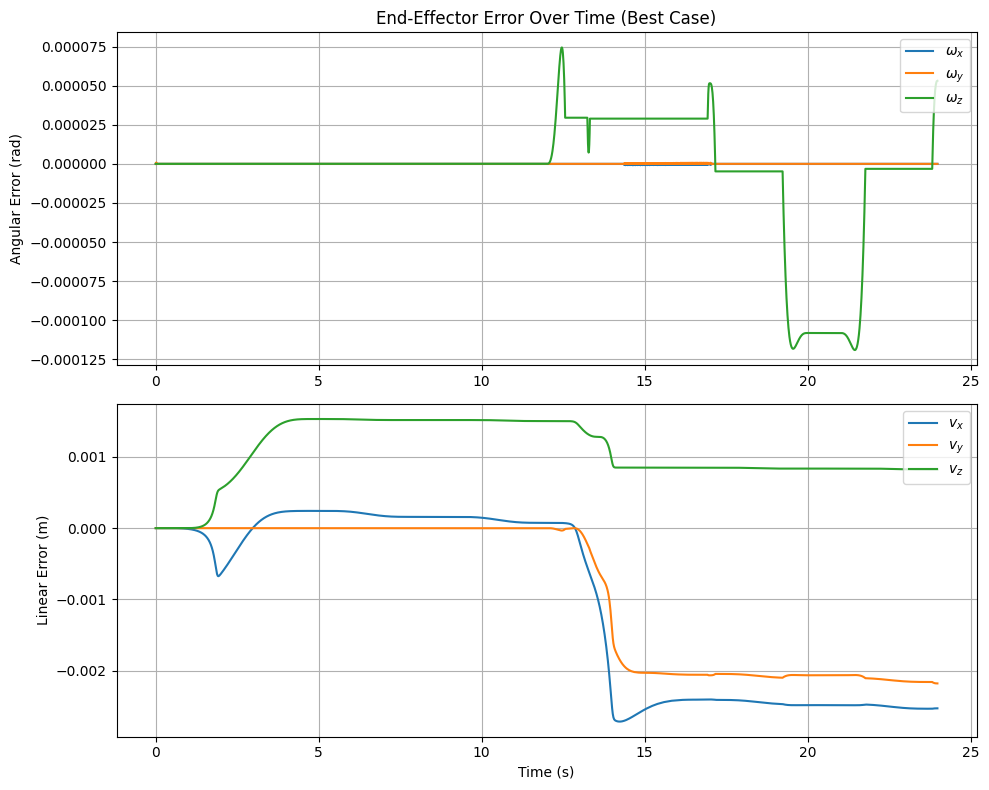

In [1580]:
#error plots 

X_err_array = np.array(X_err_list)
t_array = np.array(t)

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.plot(t_array, X_err_array[:, 0], label=r'$\omega_x$')
plt.plot(t_array, X_err_array[:, 1], label=r'$\omega_y$')
plt.plot(t_array, X_err_array[:, 2], label=r'$\omega_z$')
plt.title('End-Effector Error Over Time (Best Case)') # 
plt.ylabel('Angular Error (rad)')
plt.grid(True)
plt.legend(loc='upper right')

plt.subplot(2, 1, 2)
plt.plot(t_array, X_err_array[:, 3], label=r'$v_x$')
plt.plot(t_array, X_err_array[:, 4], label=r'$v_y$')
plt.plot(t_array, X_err_array[:, 5], label=r'$v_z$')
plt.xlabel('Time (s)')
plt.ylabel('Linear Error (m)')
plt.grid(True)
plt.legend(loc='upper right')

plt.tight_layout()
#plt.savefig('X_err_plot.png') 
plt.show()